In [4]:
import numpy as np
from PGDS_Interval_Tensor import PGDS_tensor
from tqdm.auto import tqdm
import torch
import matplotlib.pyplot as plt

In [2]:
test = np.load('/home/HuangRui/PointProcess/NodeGroup/data/icews_tensor_preprocessed_22810010013.npz', allow_pickle=True)

In [3]:
burnin = 60
maxiter = 20 
params = {
'tau': 1.,
'alpha0': 10.,
'epsilon_the': 0.,
'epsilon_lam': 1.,
'stationary': True,
'data' : torch.tensor(test['data'][:120]),
'K' : 50, # latent components
'S' : 60, # sub-intervals
'parallel' : True
}

model = PGDS_tensor(**params)
expectation_collection = []
forecast_collection = []
transition_collection = []

for iter in tqdm(range(burnin+maxiter)):
    model.sample_n()
    model.sample_h()
    model.sample_the()
    model.sample_lam()
    model.sample_delt()
    model.sample_g()
    model.sample_gam()
    model.sample_beta()
    model.sample_phi()
    model.sample_pi()

    if iter+1 > burnin:
        transition_collection.append(model.pi.clone())

  0%|          | 0/80 [00:00<?, ?it/s]

sample_n took 113.6982 seconds
sample_h took 2.6674 seconds
sample_the took 0.0019 seconds
sample_lam took 0.0004 seconds
sample_delt took 0.0174 seconds
sample_g took 0.0032 seconds
sample_gam took 0.0002 seconds
sample_beta took 0.0002 seconds
sample_phi took 5.6071 seconds
sample_pi took 0.4600 seconds
sample_n took 108.5739 seconds
sample_h took 2.9362 seconds
sample_the took 0.0019 seconds
sample_lam took 0.0003 seconds
sample_delt took 0.0195 seconds
sample_g took 0.0032 seconds
sample_gam took 0.0003 seconds
sample_beta took 0.0002 seconds
sample_phi took 6.9303 seconds
sample_pi took 0.3100 seconds
sample_n took 99.8129 seconds
sample_h took 2.5880 seconds
sample_the took 0.0024 seconds
sample_lam took 0.0004 seconds
sample_delt took 0.0187 seconds
sample_g took 0.0025 seconds
sample_gam took 0.0002 seconds
sample_beta took 0.0002 seconds
sample_phi took 6.3908 seconds
sample_pi took 0.3506 seconds
sample_n took 98.7676 seconds
sample_h took 3.1878 seconds
sample_the took 0.001

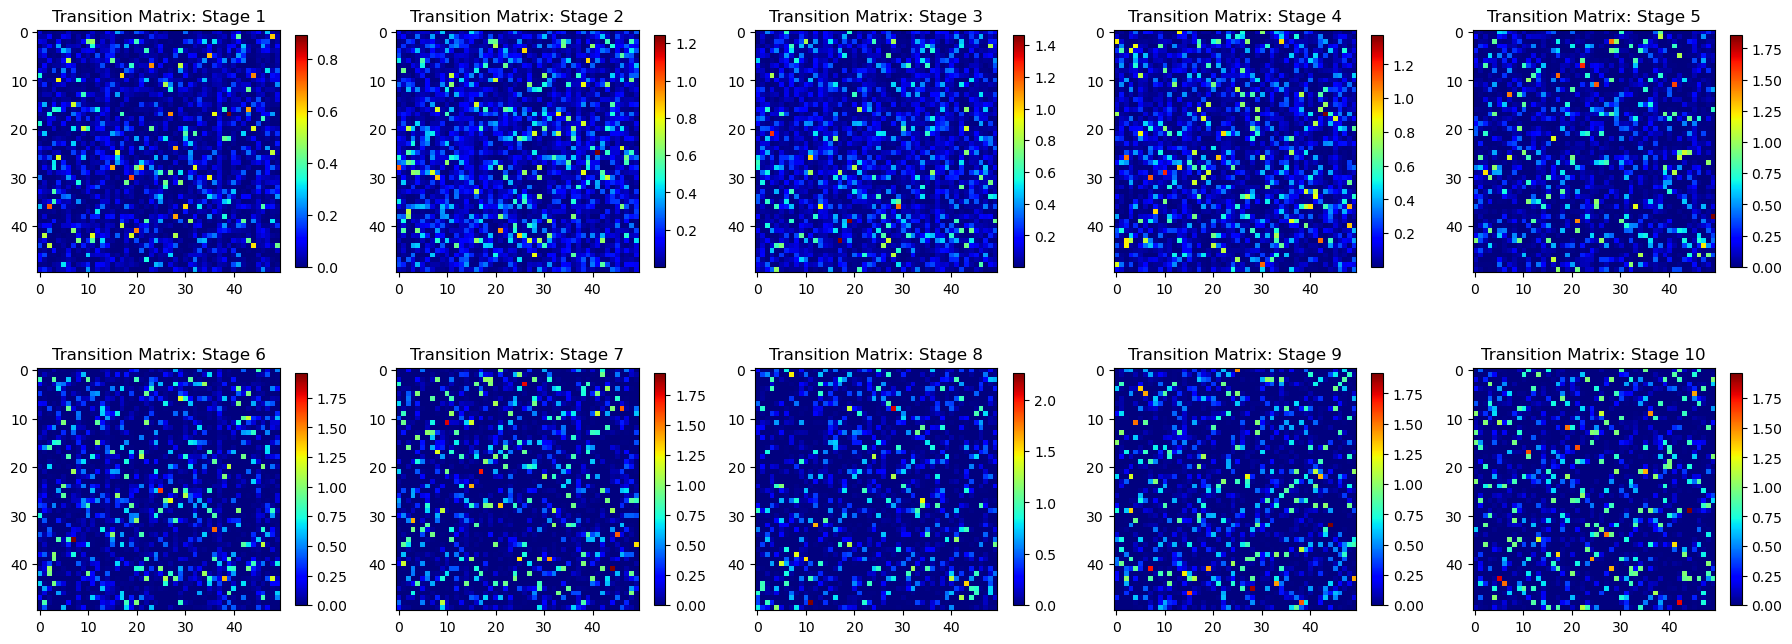

In [6]:
%matplotlib inline
transition_steady = torch.stack(transition_collection) 
transition_mean = torch.mean(transition_steady, axis = 0)
fig, axs = plt.subplots(2, 5, figsize=(18,7))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        transition_sum = np.sum(np.array(transition_mean)[3:6], axis = 0)
    else:
        transition_sum = np.sum(np.array(transition_mean)[i*6:i*6+6], axis = 0)
    im = ax.imshow(transition_sum, cmap='jet')
    ax.set_title(f'Transition Matrix: Stage {i+1}')
    # Add colorbar to each subplot
    cbar = plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

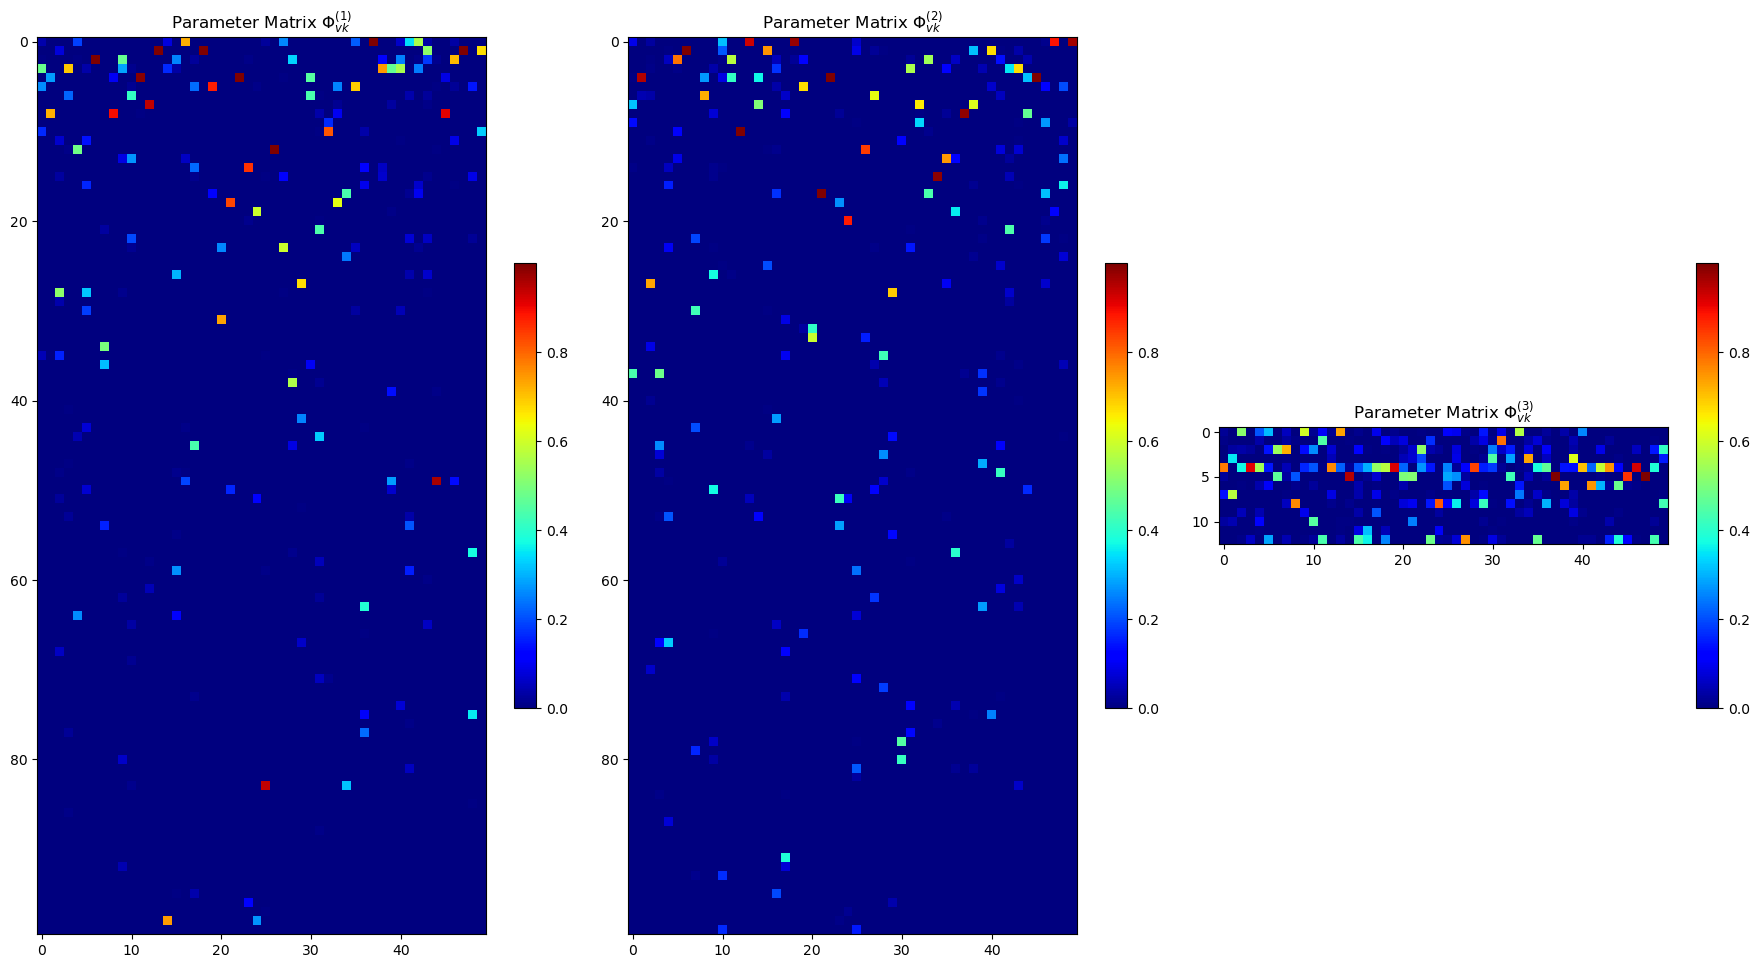

In [8]:
%matplotlib inline
fig, axs = plt.subplots(1,3, figsize = (18, 12))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        im = ax.imshow(model.phi[0], cmap = 'jet')
        ax.set_title(r'Parameter Matrix $\Phi_{vk}^{(1)}$')
        cbar = plt.colorbar(im ,ax = ax, shrink = 0.38)
    elif i == 1:
        im = ax.imshow(model.phi[1], cmap = 'jet')
        ax.set_title(r'Parameter Matrix $\Phi_{vk}^{(2)}$')
        char = plt.colorbar(im, ax = ax, shrink = 0.38)
    elif i == 2:
        im = ax.imshow(model.phi[2], cmap = 'jet')
        ax.set_title(r'Parameter Matrix $\Phi_{vk}^{(3)}$')
        char = plt.colorbar(im, ax = ax, shrink = 0.38)
plt.tight_layout()
plt.show()

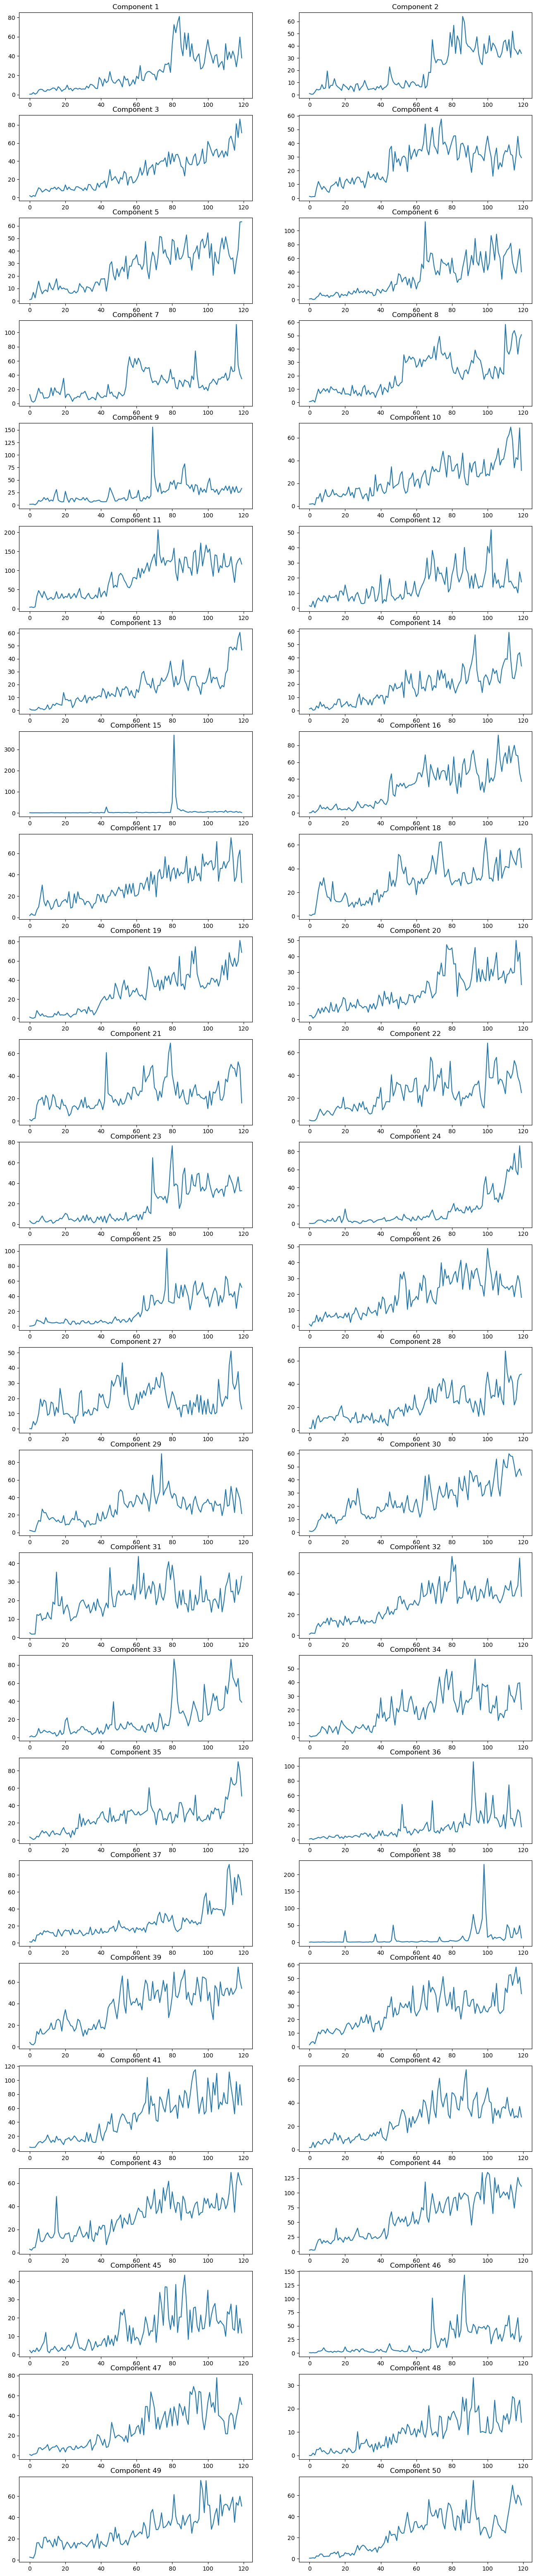

In [9]:
%matplotlib inline
fig, axs = plt.subplots(25, 2, figsize = (16,80))
for i, ax in enumerate(axs.flatten()):
    ax.plot(model.the.T[i])
    ax.set_title('Component {}'.format(i+1))
plt.show()

# Collect expectation of each iteration to compute negative log likelihood 

In [2]:
test = np.load('/home/HuangRui/PointProcess/NodeGroup/data/icews_tensor_preprocessed_33610010013.npz', allow_pickle=True)

In [ ]:
burnin = 600
maxiter = 400
params = {
'tau': 1.,
'stationary': True,
'data' : torch.tensor(test['data'][:108]),
'K' : 100, # latent components
'S' : 54, # sub-intervals
'parallel' : True
}

model = PGDS_tensor(**params)
expectation_collection = []
forecast_collection = []
transition_collection = []

for iter in tqdm(range(burnin+maxiter)):
    model.sample_n()
    model.sample_l()
    model.sample_the()
    model.sample_delt()
    model.sample_beta()
    model.sample_xi_nu()
    model.sample_phi()
    model.sample_pi()

    # compute expectation of training data
    part1 = torch.einsum('ik, jk, lk -> ijlk', model.phi[0], model.phi[1], model.phi[2])
    part2 = torch.einsum('k, tk, t -> kt', model.lam, model.the, model.delt)
    expectation = torch.einsum('ijlk, kt -> ijlt', part1, part2)
    expectation_collection.append(expectation.clone())

    if iter > burnin:
        transition_collection.append(model.pi.clone())